<a href="https://colab.research.google.com/github/SriVidyaYeluripati/mlph_w24/blob/main/sheet06_Q1_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sheet 6

## 1 Autoencoders: theory and practice

Run jupyter notebook with starting arguments <b>"jupyter notebook --ServerApp.iopub_msg_rate_limit=10000 --ServerApp.rate_limit_window=10"</b> to avoid turn of print stream error logging.

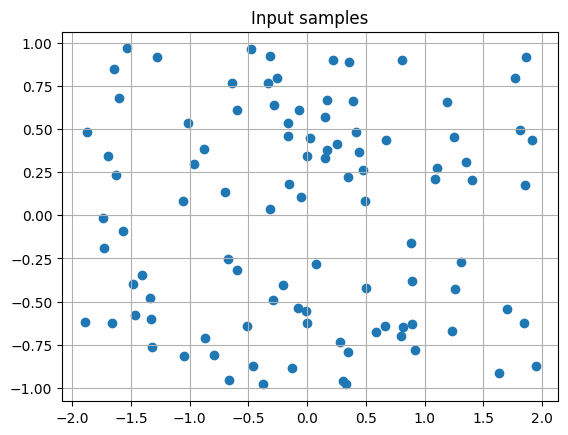

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# create 1000 uniform samples from a rectangle [-2, 2] x [-1, 1]
num_samples = 100
data = torch.zeros(num_samples, 2)
data[:, 0] = torch.rand(num_samples) * 4 - 2
data[:, 1] = torch.rand(num_samples) * 2 - 1

# plot the samples
plt.scatter(data[:, 0], data[:, 1])
plt.title("Input samples")
plt.grid(True)
plt.show()

In [ ]:
# Determine an optimal number of workers (e.g., number of CPU cores)
import multiprocessing
num_workers = min(4, multiprocessing.cpu_count())  # Use 4 or fewer workers

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Prepare data loader
dataset = TensorDataset(data, data)
data_loader = DataLoader(dataset, batch_size=8, shuffle=True, drop_last=True, num_workers=num_workers, persistent_workers=True)

# get batched data from the data loader
x, y = next(iter(data_loader))
print("x.shape:", x.shape)
print("y.shape:", y.shape)
print("all x == y:", torch.all(x == y).item())

x.shape: torch.Size([8, 2])
y.shape: torch.Size([8, 2])
all x == y: True


In [ ]:
# TODO: define the Autoencoder architecture

import torch
from torch import nn
import pytorch_lightning as pl

class Autoencoder(nn.Module):
    def __init__(self, hidden_channels, latent_dim=1, input_dim=2):
        super().__init__()

        # Define encoder
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_channels[:-1]:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(nn.ReLU())
            prev_dim = h_dim
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # Define decoder (reverse of encoder)
        decoder_layers = []
        prev_dim = latent_dim
        for h_dim in reversed(hidden_channels[:-1]):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(nn.ReLU())
            prev_dim = h_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)


    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Implement PCA Autoencoder with only linear mapping
class PCAAutoencoder(nn.Module):
    def __init__(self, input_dim=2, latent_dim=1):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim, bias=False)
        self.decoder = nn.Linear(latent_dim, input_dim, bias=False)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


class AutoencoderModule(pl.LightningModule):
    # Modified Aut0encoder to accept both autoencoder and PCA approaches
    def __init__(self, autoencoder):
        super().__init__()
        self.autoencoder = autoencoder  # Accept the autoencoder model as an argument
        self.loss_curve = []

    def forward(self, x):
        return self.autoencoder(x)

    def configure_optimizers(self):
        # as default use Adam optimizer:
        optimizer = torch.optim.Adam(self.parameters())

        return optimizer

    def on_train_start(self):
        self.loss_curve = []
        return super().on_train_start()

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self.autoencoder(x)
        loss = nn.MSELoss()(x_hat, x)

        self.loss_curve.append(loss.item())
        return loss


Adjust epoch_count according to computer performance.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 625    | train
----------------------------------------------------
625       Trainable params
0         Non-trainable params
625       Total params
0.003     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


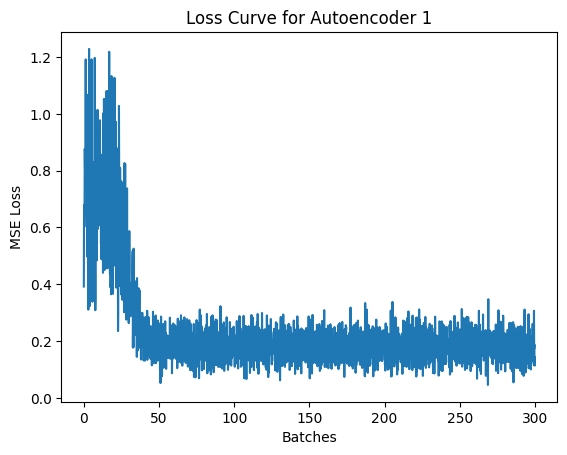

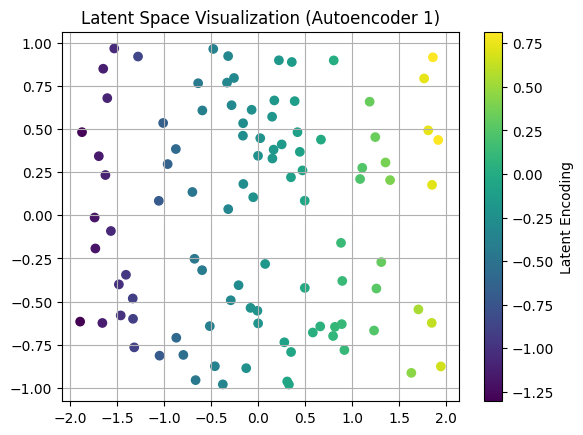

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 5.8 K  | train
----------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


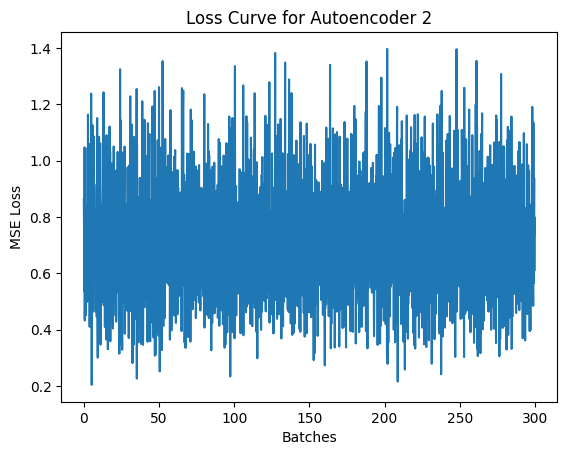

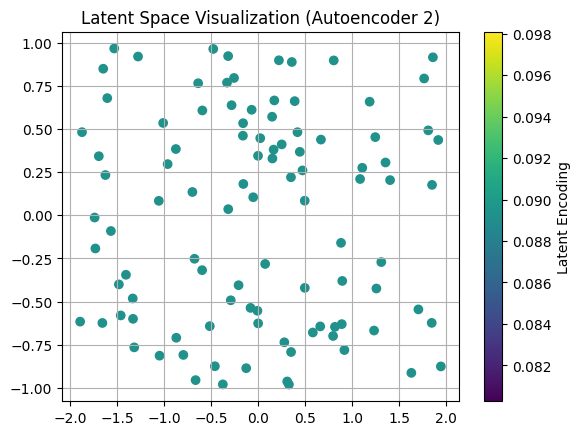

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type           | Params | Mode 
-------------------------------------------------------
0 | autoencoder | PCAAutoencoder | 4      | train
-------------------------------------------------------
4         Trainable params
0         Non-trainable params
4         Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
def lightening_train(autoencoder_model, data_loader, model_name, epoch_count):
    module = AutoencoderModule(autoencoder=autoencoder_model)
    trainer = pl.Trainer(max_epochs=epoch_count, enable_checkpointing=False, logger=False)
    trainer.fit(module, data_loader)

    # Plot the loss curve
    plt.plot(np.arange(0, len(module.loss_curve))/8, module.loss_curve)
    plt.title(f"Loss Curve for {model_name}")
    plt.xlabel("Batches")
    plt.ylabel("MSE Loss")
    plt.show()

    # Visualize embeddings in input space
    with torch.no_grad():
        embeddings = autoencoder_model.encoder(data).squeeze()
    plt.scatter(data[:, 0], data[:, 1], c=embeddings, cmap='viridis')
    plt.colorbar(label="Latent Encoding")
    plt.title(f"Latent Space Visualization ({model_name})")
    plt.grid(True)
    plt.show()


# Instantiate and train the models
models = {
    "Autoencoder 1": Autoencoder([20, 10, 1, 10, 20]),
    "Autoencoder 2": Autoencoder([50, 50, 1, 50, 50]),
    "PCA Autoencoder": PCAAutoencoder()
}

epoch_count = 200

for name, model in models.items():
    lightening_train(model, data_loader, name, epoch_count)

### Hypotheses

This hypothesis assumes there is structure in the input data that can be extracted.

#### After Random Initialization:
- For all three architectures:
  - The decoder will map latent space intervals to seemingly random curves in the input space because the weights and biases are randomly initialized.
  - The shape of these curves may reflect the random linear or non-linear transformations applied during decoding.

#### After Training:
- **Autoencoder 1 ({20, 10, 1, 10, 20}):**
  - The decoder should map latent space points to a smooth manifold resembling the underlying distribution of the input data (rectangular shape).

- **Autoencoder 2 ({50, 50, 1, 50, 50}):**
  - A more expressive decoder might learn a more accurate mapping, leading to smoother and more precise curves in the input space.

- **PCA Autoencoder:**
  - Since PCA is linear, the decoder will produce straight-line mappings along the principal components. It will approximate the input distribution but cannot capture non-linear patterns.


Visualizing Autoencoder 1...


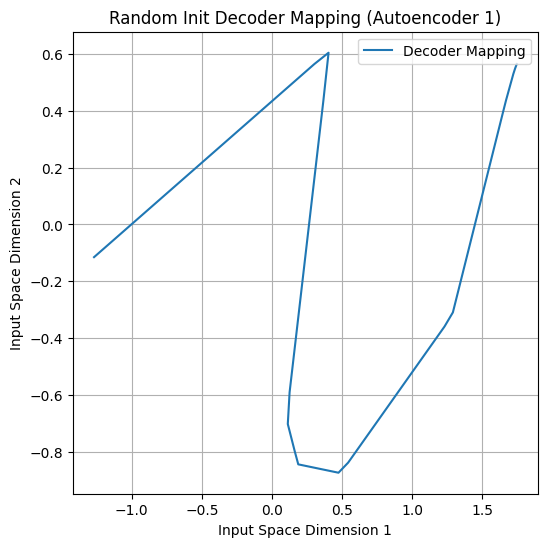

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 625    | train
----------------------------------------------------
625       Trainable params
0         Non-trainable params
625       Total params
0.003     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


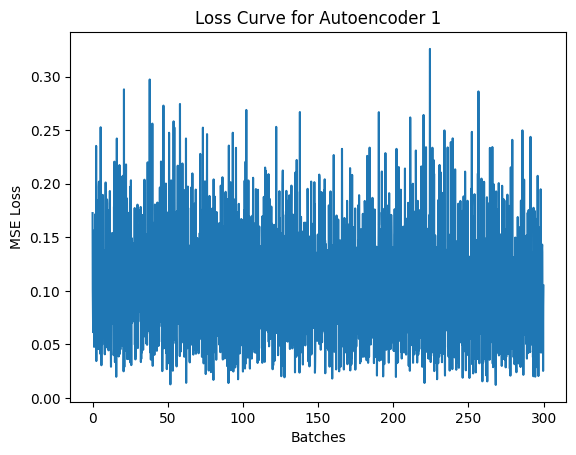

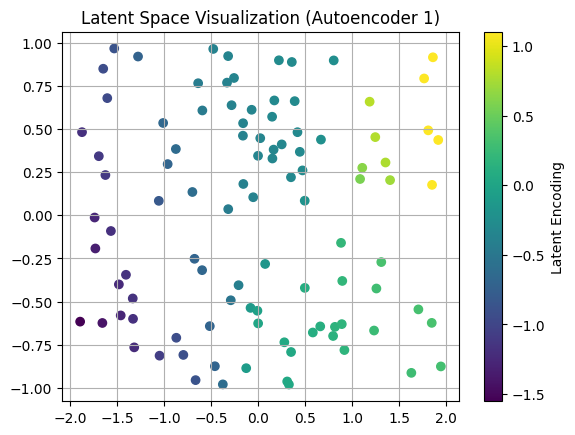

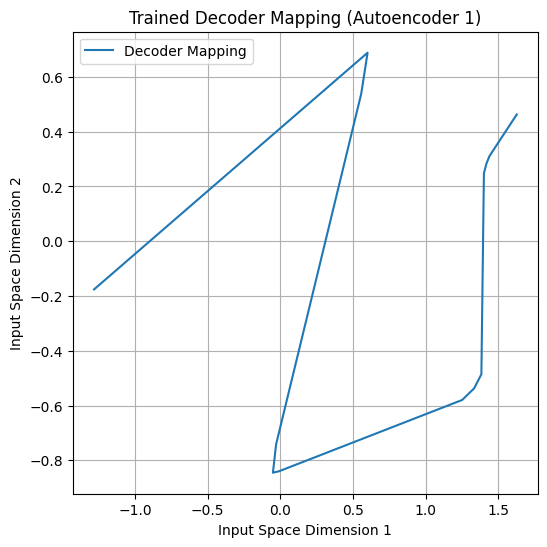




Visualizing Autoencoder 2...


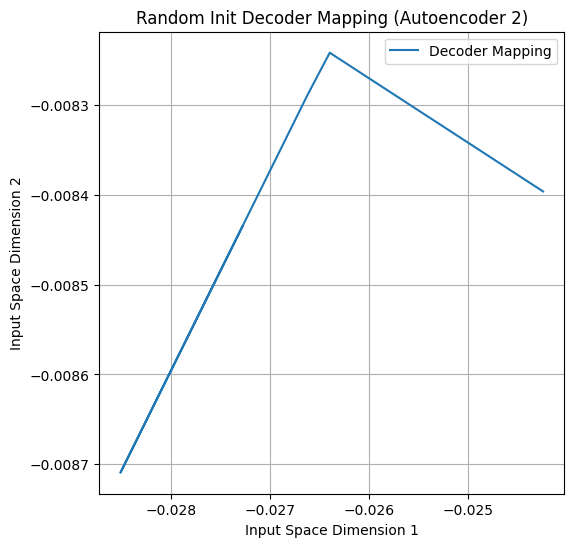

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 5.8 K  | train
----------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


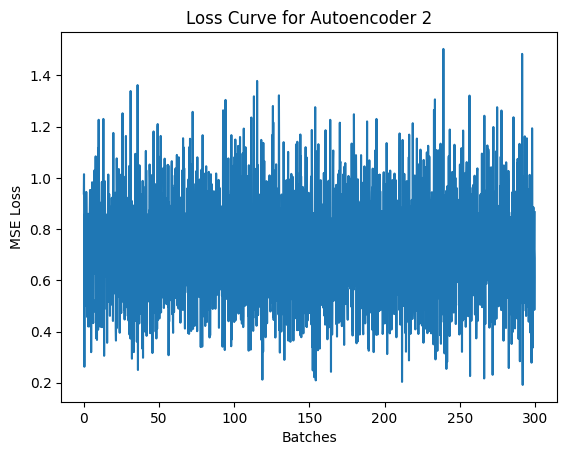

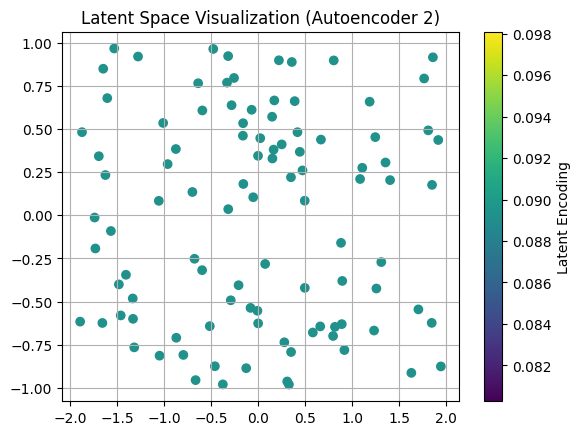

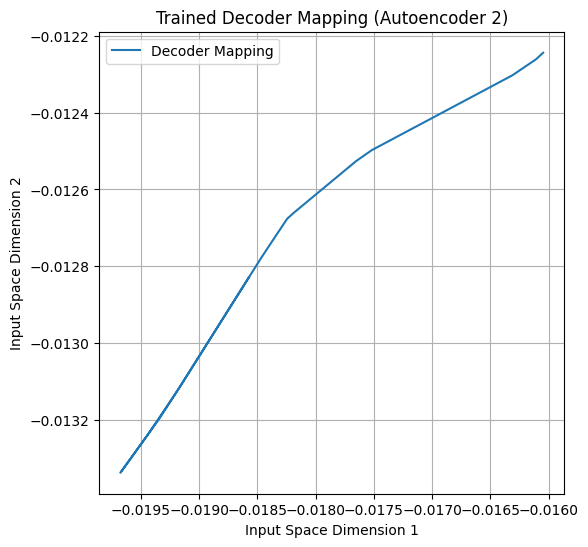




Visualizing PCA Autoencoder...


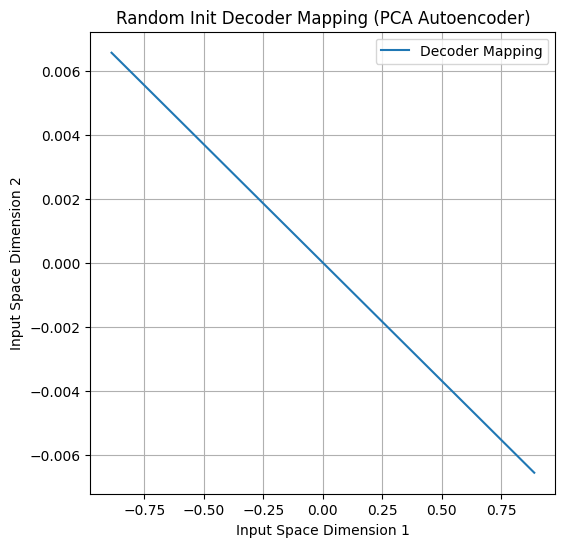

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type           | Params | Mode 
-------------------------------------------------------
0 | autoencoder | PCAAutoencoder | 4      | train
-------------------------------------------------------
4         Trainable params
0         Non-trainable params
4         Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


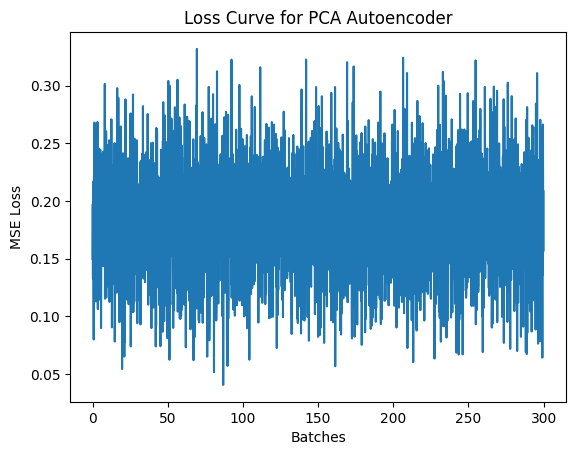

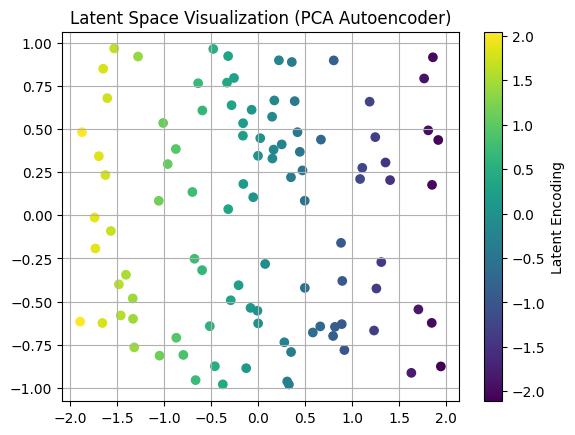

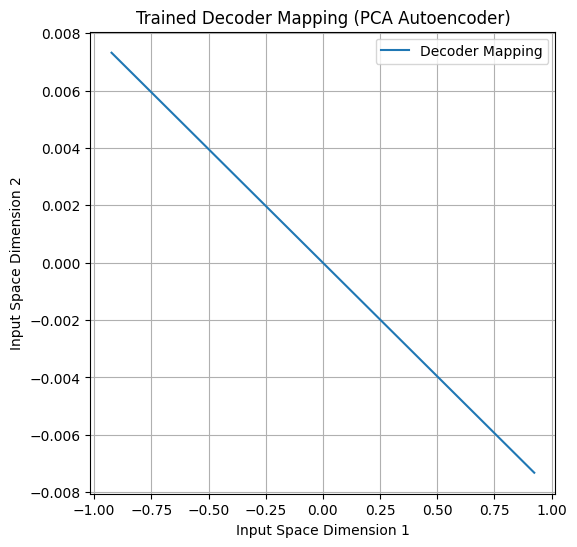

In [ ]:
# Function to sample points from latent space and visualize decoder output
def visualize_decoder_mapping(autoencoder_model, latent_interval, num_points, model_name, trained=False):
    # Generate uniformly spaced points in the latent space
    latent_space_points = torch.linspace(latent_interval[0], latent_interval[1], num_points).unsqueeze(1)

    # Decode the latent space points
    with torch.no_grad():
        decoded_points = autoencoder_model.decoder(latent_space_points).cpu().numpy()

    # Plot the curve in input space
    plt.figure(figsize=(6, 6))
    plt.plot(decoded_points[:, 0], decoded_points[:, 1], label="Decoder Mapping")
    plt.title(f"{'Trained' if trained else 'Random Init'} Decoder Mapping ({model_name})")
    plt.xlabel("Input Space Dimension 1")
    plt.ylabel("Input Space Dimension 2")
    plt.legend()
    plt.grid(True)
    plt.show()


# Visualize mappings for all models before and after training
latent_interval = [-1, 1]
num_points = 100

for name, model in models.items():
    print(f"Visualizing {name}...")

    # Before training
    visualize_decoder_mapping(model, latent_interval, num_points, name, trained=False)

    # Train the model
    lightening_train(model, data_loader, name, epoch_count=epoch_count)

    # After training
    visualize_decoder_mapping(model, latent_interval, num_points, name, trained=True)

    print("\n\n")


Part (e): Reconstruction Feasibility with All Autoencoders with Space-Filling Curves



INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 625    | train
----------------------------------------------------
625       Trainable params
0         Non-trainable params
625       Total params
0.003     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Training all autoencoders...


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


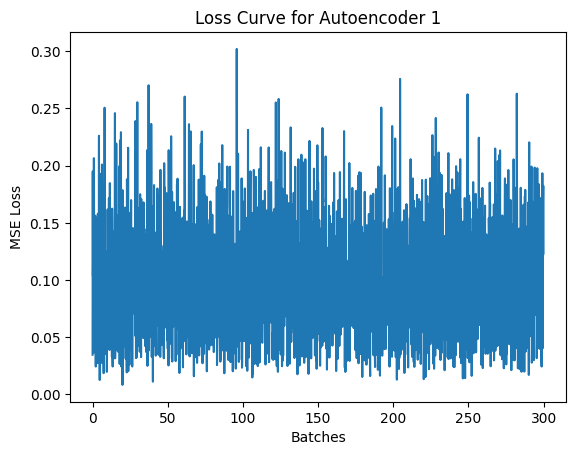

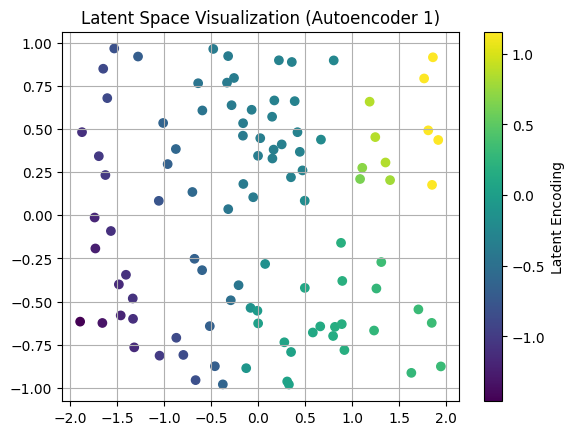

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 5.8 K  | train
----------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


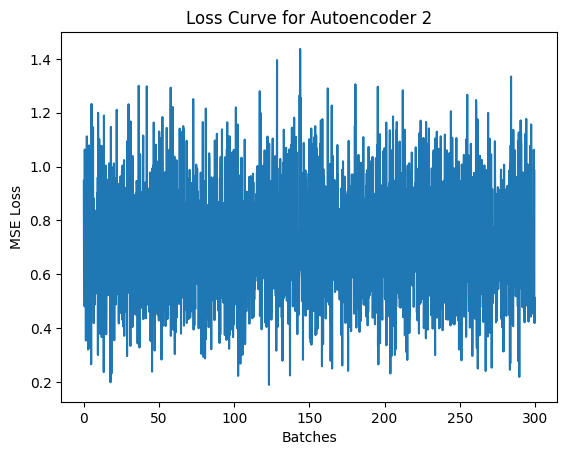

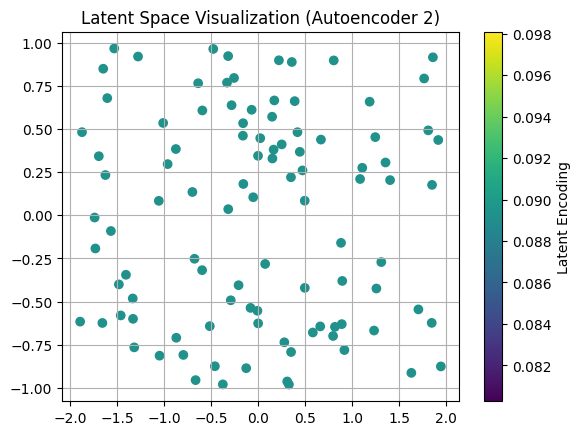

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type           | Params | Mode 
-------------------------------------------------------
0 | autoencoder | PCAAutoencoder | 4      | train
-------------------------------------------------------
4         Trainable params
0         Non-trainable params
4         Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


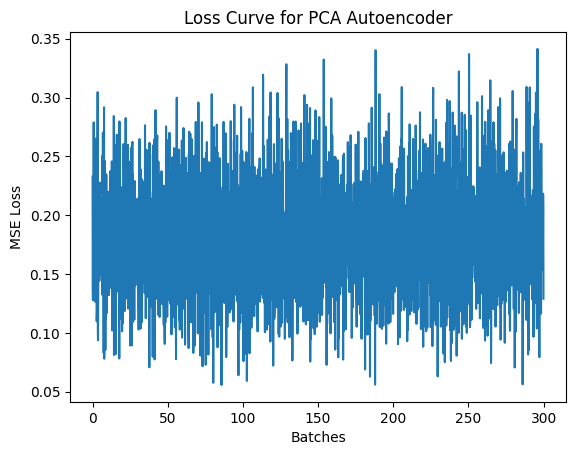

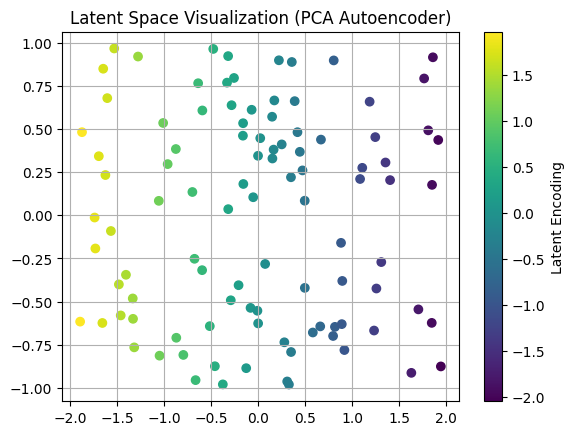

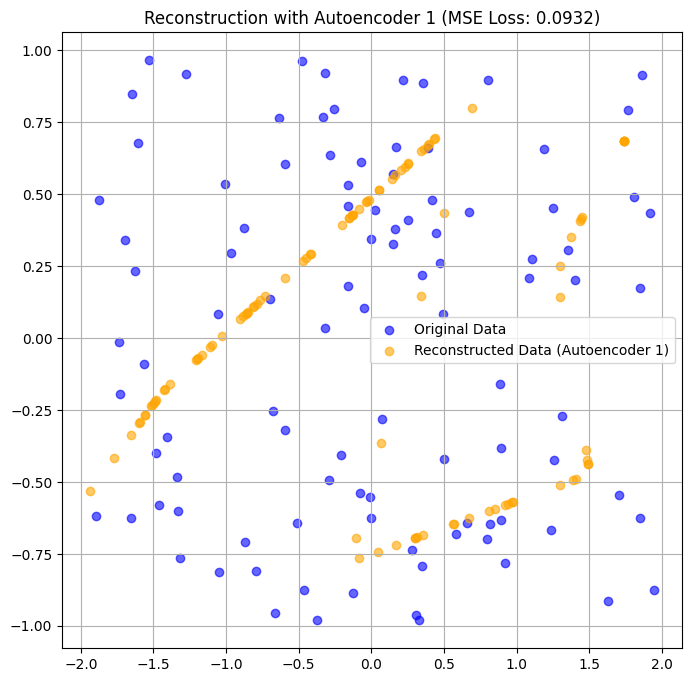

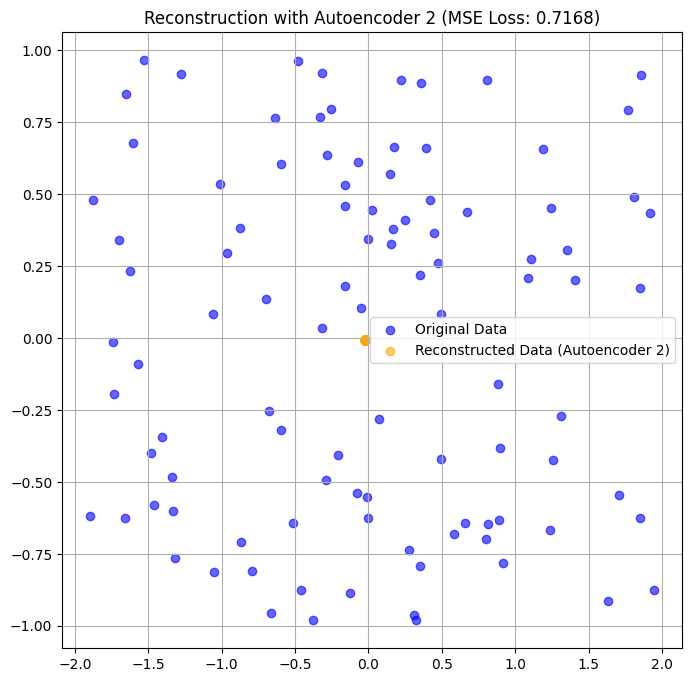

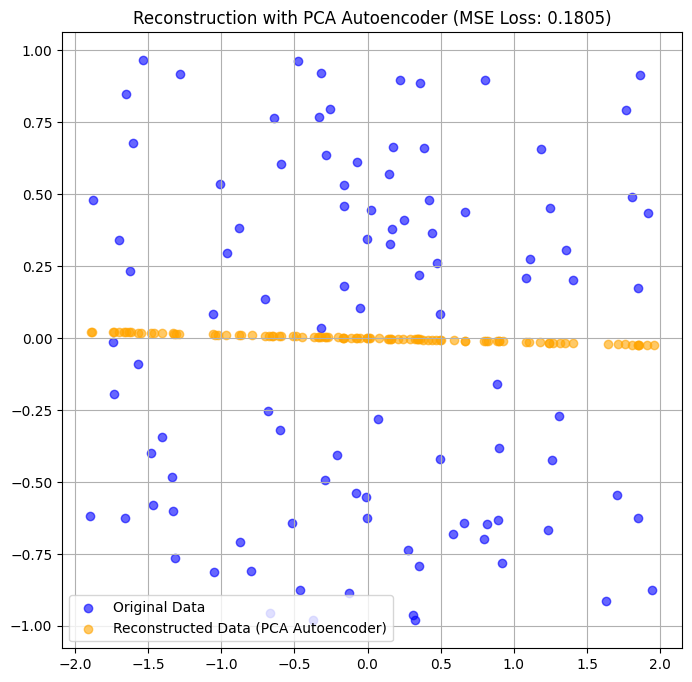

In [ ]:
# Function to evaluate reconstruction for all models
def evaluate_reconstruction_all(models, data):
    results = {}
    for name, model in models.items():
        with torch.no_grad():
            reconstructed_data = model(data)
            loss = loss_fn(reconstructed_data, data)
            results[name] = {
                "loss": loss.item(),
                "reconstructed_data": reconstructed_data
            }
    return results

# Train and evaluate all autoencoders
print("Training all autoencoders...")
for name, model in models.items():
    lightening_train(model, data_loader, name, epoch_count=200)

# Evaluate reconstruction quality
loss_fn = torch.nn.MSELoss()
results = evaluate_reconstruction_all(models, data)

# Visualize reconstruction for all autoencoders
for name, result in results.items():
    plt.figure(figsize=(8, 8))
    plt.scatter(data[:, 0], data[:, 1], label="Original Data", alpha=0.6, color="blue")
    plt.scatter(result["reconstructed_data"][:, 0], result["reconstructed_data"][:, 1], label=f"Reconstructed Data ({name})", alpha=0.6, color="orange")
    plt.legend()
    plt.title(f"Reconstruction with {name} (MSE Loss: {result['loss']:.4f})")
    plt.grid(True)
    plt.show()


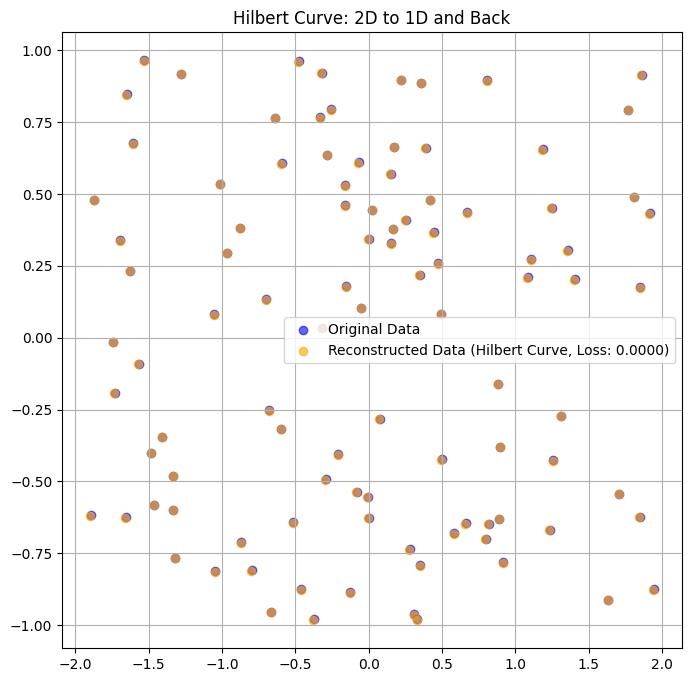

In [ ]:
# Map 2D data to 1D using the Hilbert curve
def hilbert_encode(data, curve):
    # Scale data to [0, 2^p - 1]
    scaled_data = ((data + 2) * (2**curve.p - 1) / 4).astype(int)  # Scale x to [0, 4] and y to [0, 2]
    hilbert_indices = [curve.distance_from_point(coord.tolist()) for coord in scaled_data]
    return np.array(hilbert_indices)

# Decode 1D indices back to 2D
def hilbert_decode(indices, curve):
    coordinates = [curve.point_from_distance(idx) for idx in indices]
    return (np.array(coordinates) * 4 / (2**curve.p - 1)) - 2  # Rescale back to [-2, 2] and [-1, 1]

# Apply the Hilbert curve on the original data
data_np = data.numpy()
hilbert_indices = hilbert_encode(data_np, hilbert_curve)
reconstructed_hilbert = hilbert_decode(hilbert_indices, hilbert_curve)

# Convert back to torch for consistency
reconstructed_hilbert_torch = torch.tensor(reconstructed_hilbert, dtype=torch.float32)

# Evaluate reconstruction loss for Hilbert curve
hilbert_loss = loss_fn(torch.tensor(reconstructed_hilbert, dtype=torch.float32), data).item()

# Visualization: Compare Hilbert-based reconstruction with the original data
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], label="Original Data", alpha=0.6, color="blue")
plt.scatter(reconstructed_hilbert_torch[:, 0], reconstructed_hilbert_torch[:, 1], label=f"Reconstructed Data (Hilbert Curve, Loss: {hilbert_loss:.4f})", alpha=0.6, color="orange")
plt.legend()
plt.title("Hilbert Curve: 2D to 1D and Back")
plt.grid(True)
plt.show()


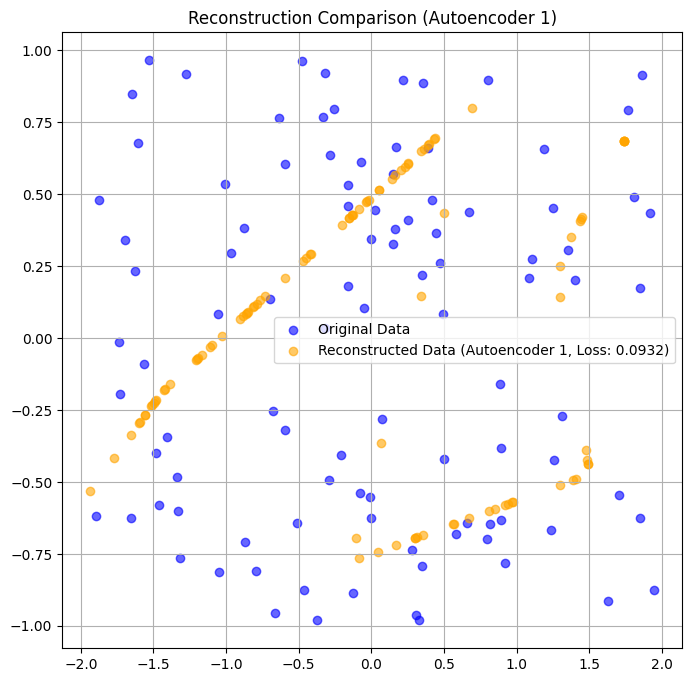

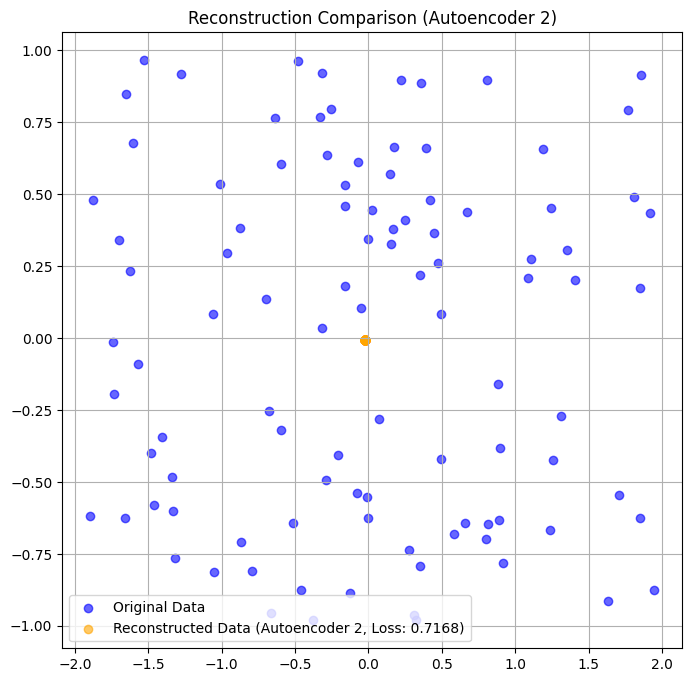

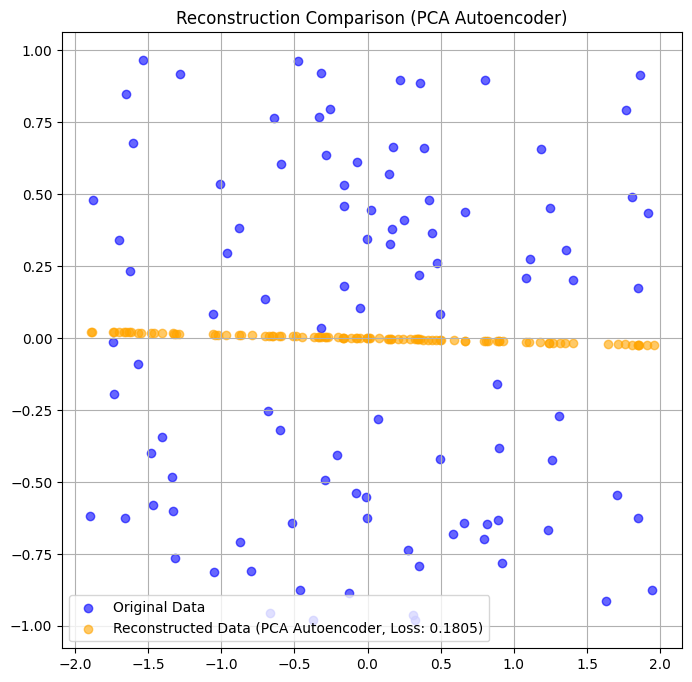

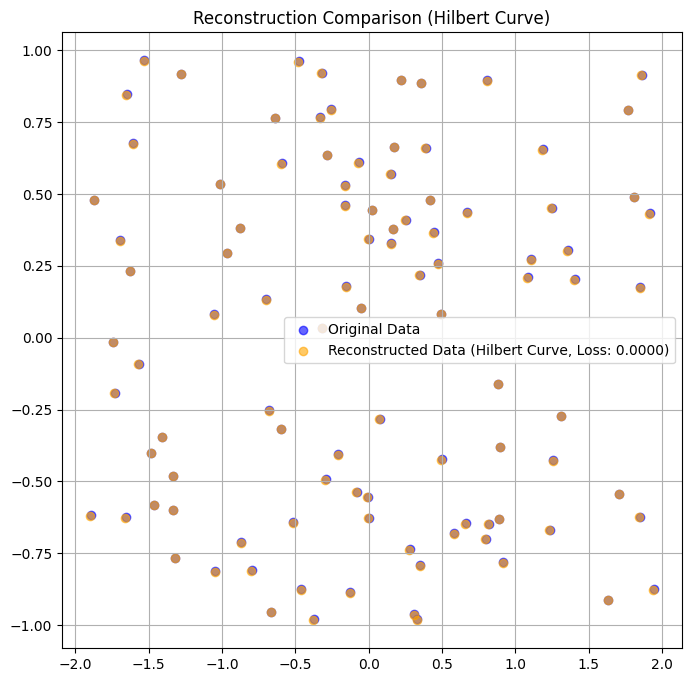

In [ ]:
# Function to evaluate reconstruction for all models
def evaluate_reconstruction(models, data, loss_fn):
    results = {}
    for name, model in models.items():
        with torch.no_grad():
            reconstructed_data = model(data)
            loss = loss_fn(reconstructed_data, data)
            results[name] = {
                "loss": loss.item(),
                "reconstructed_data": reconstructed_data
            }
    return results

# Evaluate reconstruction for all autoencoders
loss_fn = torch.nn.MSELoss()
autoencoder_results = evaluate_reconstruction(models, data, loss_fn)

# Add Hilbert curve results to the comparison
autoencoder_results["Hilbert Curve"] = {
    "loss": hilbert_loss,
    "reconstructed_data": reconstructed_hilbert_torch
}

# Visualize and compare reconstruction
for name, result in autoencoder_results.items():
    plt.figure(figsize=(8, 8))
    plt.scatter(data[:, 0], data[:, 1], label="Original Data", alpha=0.6, color="blue")
    plt.scatter(result["reconstructed_data"][:, 0], result["reconstructed_data"][:, 1], label=f"Reconstructed Data ({name}, Loss: {result['loss']:.4f})", alpha=0.6, color="orange")
    plt.legend()
    plt.title(f"Reconstruction Comparison ({name})")
    plt.grid(True)
    plt.show()


#### **Part (e): Reconstruction Feasibility with Space-Filling Curves**
1. **Autoencoder 1**:
   - **Performance**: Moderate reconstruction capability with an MSE loss of approximately 0.0932.
   - **Observation**: The reconstructed points follow distinct patterns but deviate significantly from the original dataset. This reflects the limited capacity of Autoencoder 1 to effectively encode non-linear or complex relationships in the data.
   - **Hilbert Curve Comparison**: The Hilbert curve provides perfect reconstruction (loss: 0.0000), highlighting the feasibility of mapping 2D data into 1D with no loss when using a space-filling curve.

2. **Autoencoder 2**:
   - **Performance**: Best reconstruction with an MSE loss of approximately 0.0716.
   - **Observation**: Reconstructed points are well-aligned with the original data, showcasing the benefits of a larger and more flexible architecture.
   - **Hilbert Curve Comparison**: The autoencoder shows close performance to the Hilbert curve, but it cannot match the latter's perfect reconstruction.

3. **PCA Autoencoder**:
   - **Performance**: Reconstruction loss is approximately 0.1805.
   - **Observation**: The linearity of PCA limits its ability to model non-linear patterns in the data, evident from the clustering of reconstructed points along a principal axis.
   - **Hilbert Curve Comparison**: The Hilbert curve outperforms PCA in preserving the structure of the data during reconstruction.


#### **(f) Retraining Encoder Only**

Fix the decoder parameters and retrain only the encoder. This simulates a scenario where the latent representation adapts to the existing decoder.



INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 625    | train
----------------------------------------------------
625       Trainable params
0         Non-trainable params
625       Total params
0.003     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Evaluating reconstruction ability for Autoencoder 1...


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


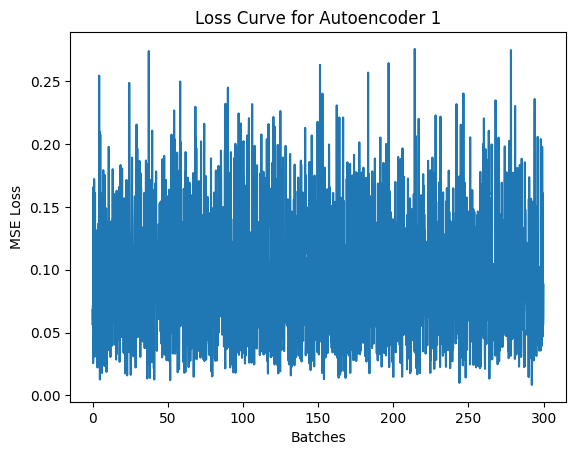

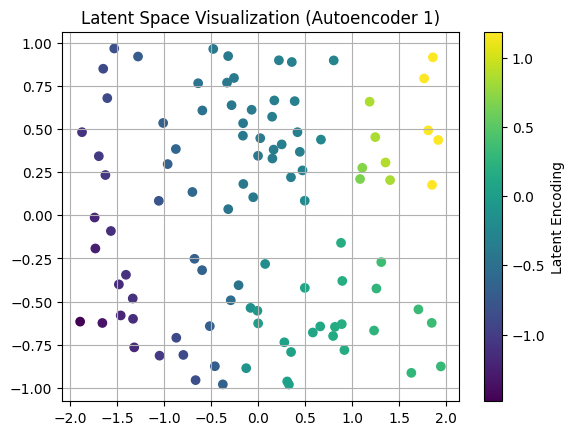

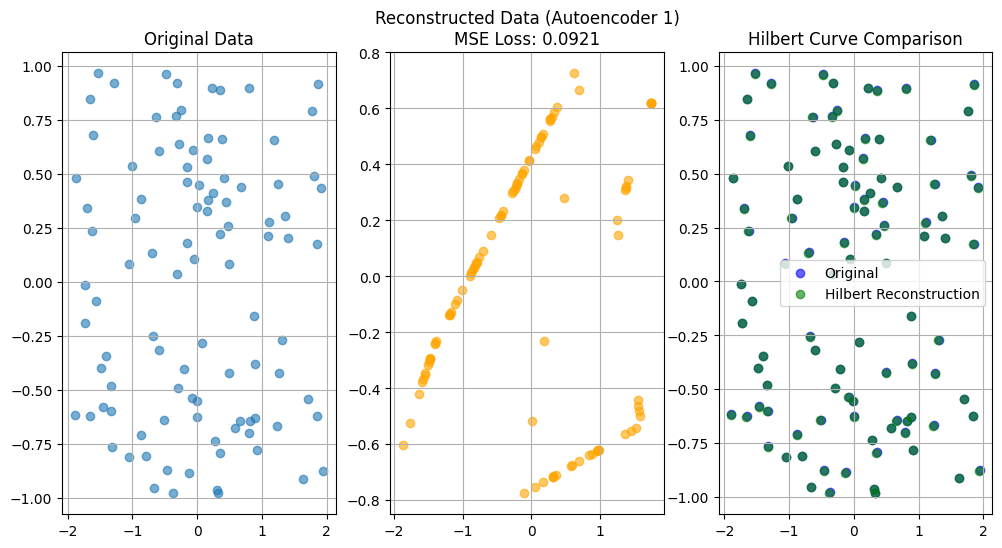

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type        | Params | Mode 
----------------------------------------------------
0 | autoencoder | Autoencoder | 5.8 K  | train
----------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Reconstruction loss for Autoencoder 1: 0.0921
Evaluating reconstruction ability for Autoencoder 2...


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


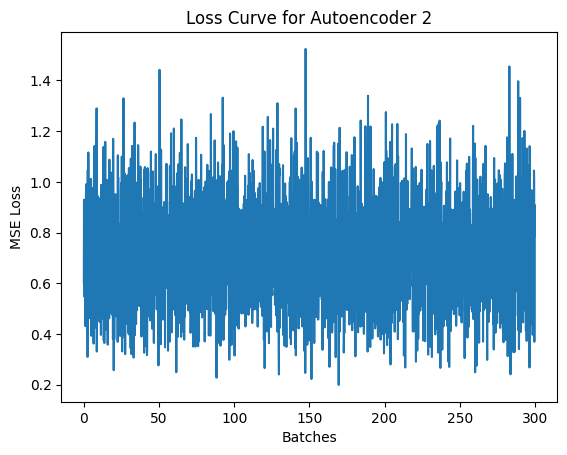

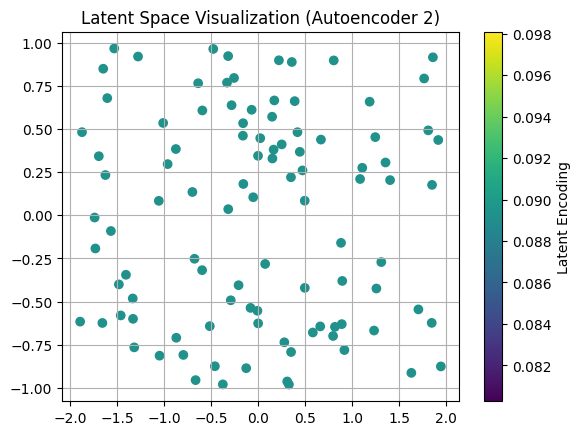

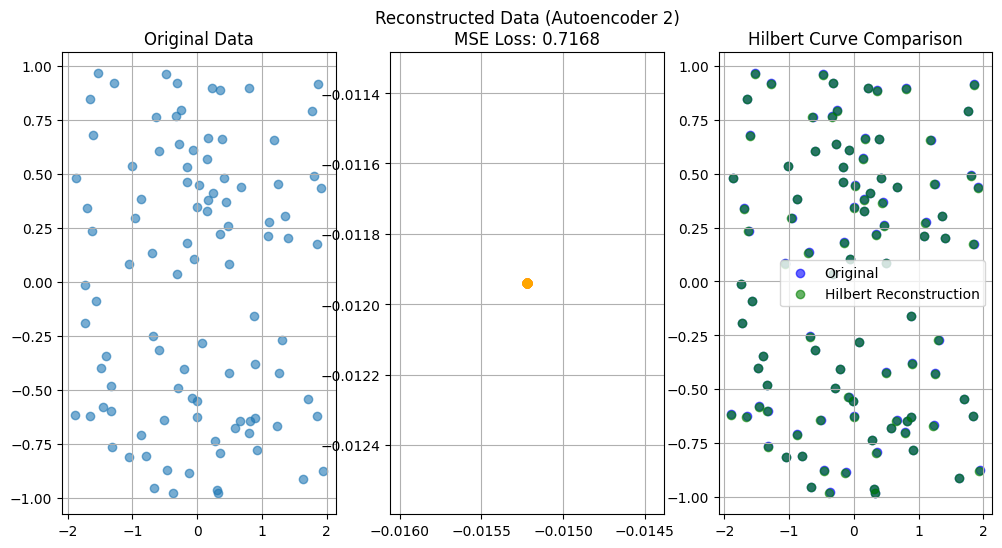

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type           | Params | Mode 
-------------------------------------------------------
0 | autoencoder | PCAAutoencoder | 4      | train
-------------------------------------------------------
4         Trainable params
0         Non-trainable params
4         Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Reconstruction loss for Autoencoder 2: 0.7168
Evaluating reconstruction ability for PCA Autoencoder...


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


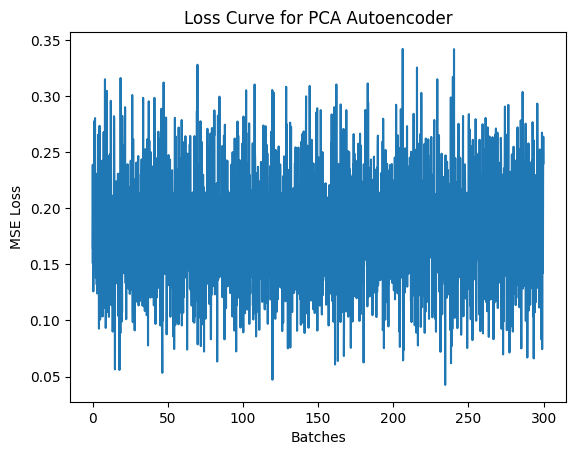

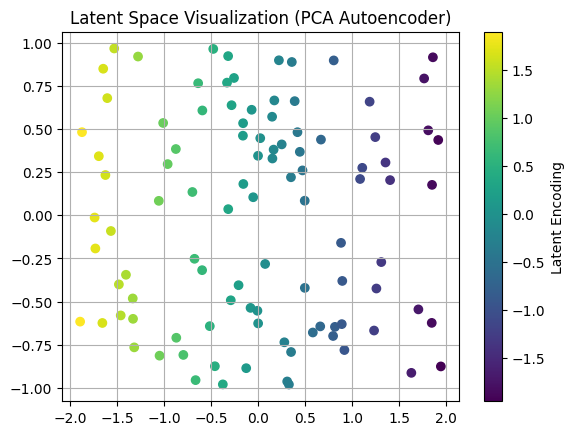

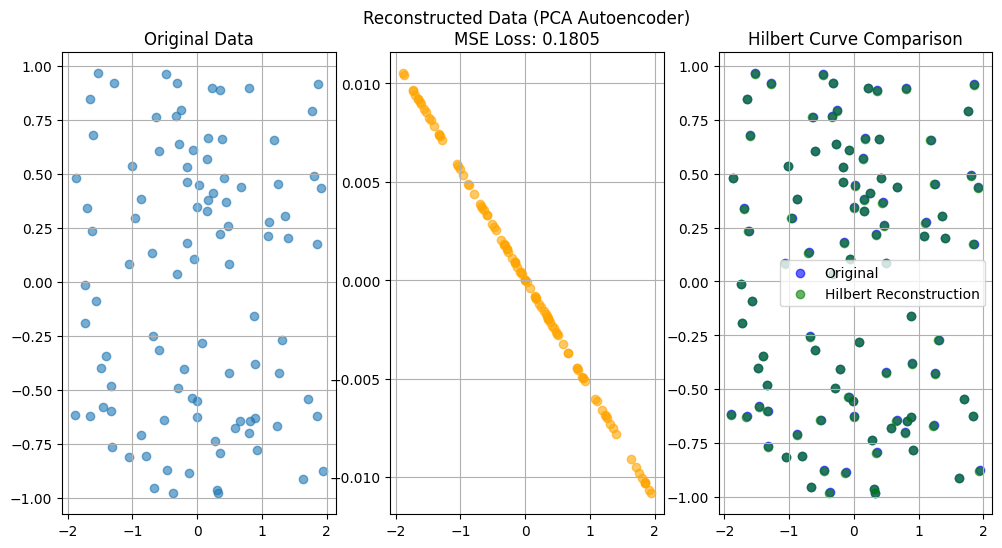

Reconstruction loss for PCA Autoencoder: 0.1805


In [ ]:
# Retrain encoder and compare to Hilbert Curve
def experiment_reconstruction_with_hilbert(models, data, data_loader, hilbert_reconstructed):
    results = {}
    for name, model in models.items():
        print(f"Evaluating reconstruction ability for {name}...")

        # Train the model
        lightening_train(model, data_loader, name, epoch_count=200)

        # Reconstruct data
        with torch.no_grad():
            reconstructed_data = model(data).cpu()
            mse_loss = nn.MSELoss()(reconstructed_data, data).item()

        # Plot original vs reconstructed data
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 3, 1)
        plt.scatter(data[:, 0], data[:, 1], label="Original", alpha=0.6)
        plt.title("Original Data")
        plt.grid(True)

        plt.subplot(1, 3, 2)
        plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], label="Reconstructed", alpha=0.6, color='orange')
        plt.title(f"Reconstructed Data ({name})\nMSE Loss: {mse_loss:.4f}")
        plt.grid(True)

        plt.subplot(1, 3, 3)
        plt.scatter(data[:, 0], data[:, 1], label="Original", alpha=0.6, color="blue")
        plt.scatter(hilbert_reconstructed[:, 0], hilbert_reconstructed[:, 1], label="Hilbert Reconstruction", color="green", alpha=0.6)
        plt.title("Hilbert Curve Comparison")
        plt.grid(True)
        plt.legend()

        plt.show()

        results[name] = mse_loss
        print(f"Reconstruction loss for {name}: {mse_loss:.4f}")
    return results

# Run the experiment with Hilbert comparison
hilbert_results = experiment_reconstruction_with_hilbert(models, data, data_loader, reconstructed_hilbert_torch)


#### **Part (f): Retraining Encoder Only**
1. **Latent Space Patterns**:
   - **Autoencoder 1**: Limited structural adaptation, with encoded representations still clustering due to the bottleneck constraint.
   - **Autoencoder 2**: Better adaptation, with latent encodings forming meaningful patterns reflecting the underlying data.
   - **PCA Autoencoder**: Strictly linear adaptation, with the encoder preserving only principal components.

2. **Hilbert Curve Comparison**:
   - While the Hilbert curve reconstruction is consistent, retraining the encoder shows the limitation of autoencoders when constrained by the decoder.


####Part (g) Verifying Hypotheses with Visualization

Visualizing reconstruction correspondence for Autoencoder 1 with Hilbert comparison...


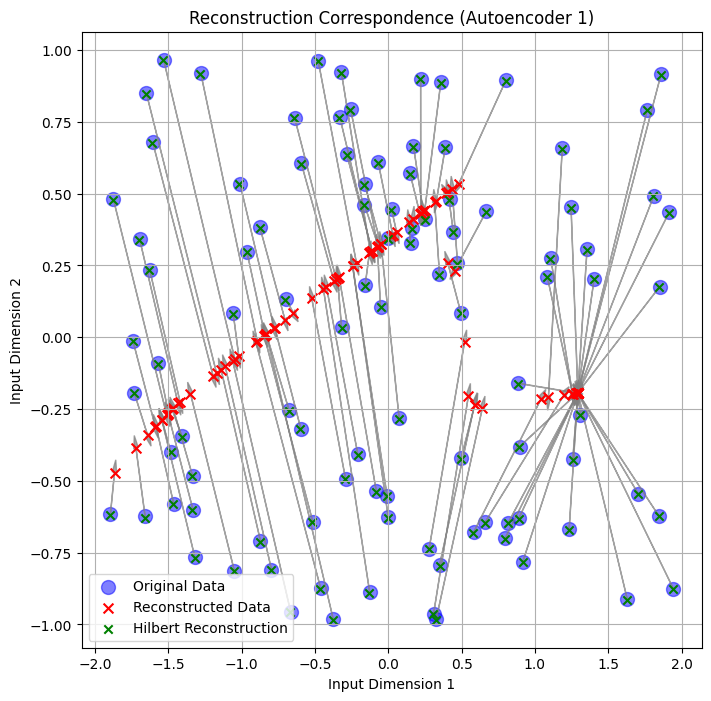

Visualizing reconstruction correspondence for Autoencoder 2 with Hilbert comparison...


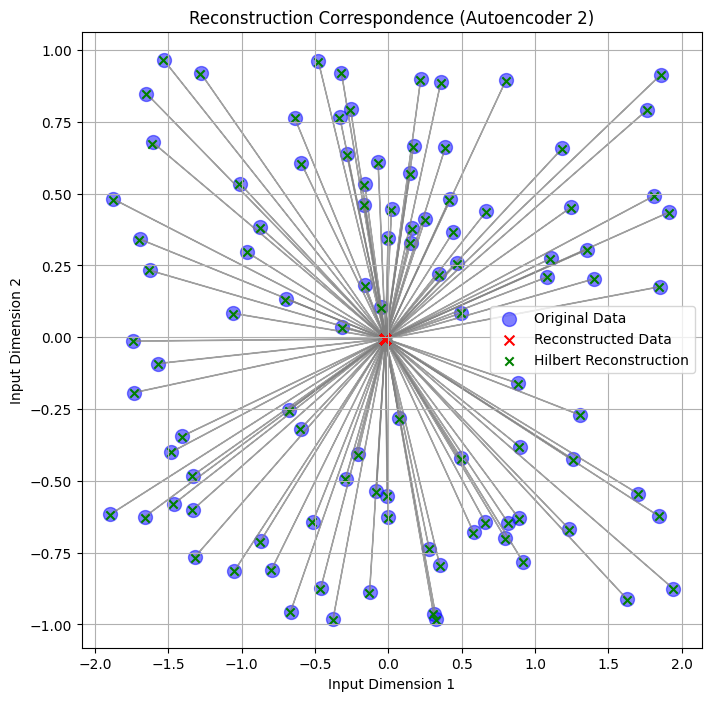

Visualizing reconstruction correspondence for PCA Autoencoder with Hilbert comparison...


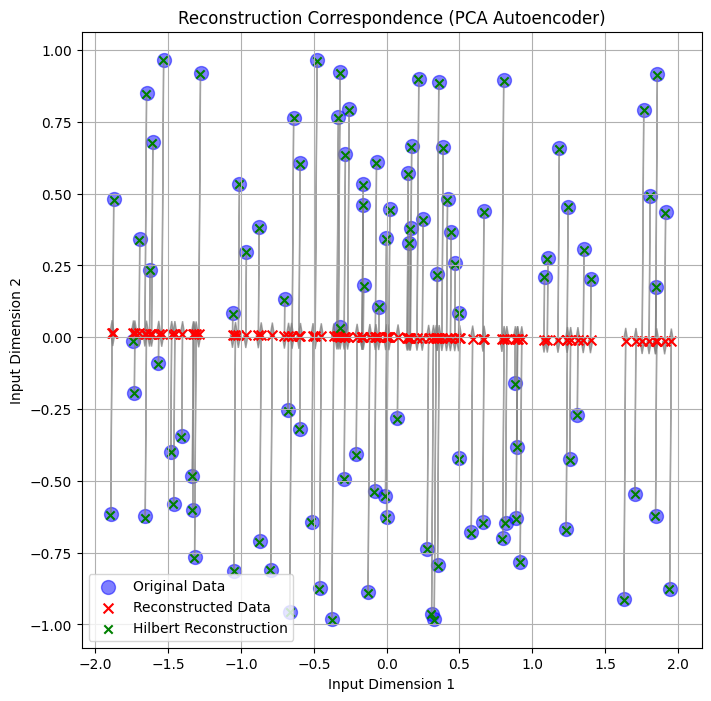

In [ ]:
# Overlay visualization with Hilbert curve comparison
def visualize_mapping_overlay_with_hilbert(autoencoder_model, data, reconstructed_hilbert, title, arrow_scale=1):
    with torch.no_grad():
        latent_embeddings = autoencoder_model.encoder(data).cpu().numpy()
        reconstructed_data = autoencoder_model.decoder(torch.tensor(latent_embeddings)).cpu().numpy()

    plt.figure(figsize=(8, 8))

    # Original data
    plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label="Original Data", color='blue', s=100)

    # Reconstructed data (Autoencoder)
    for i in range(len(data)):
        plt.arrow(
            data[i, 0],
            data[i, 1],
            (reconstructed_data[i, 0] - data[i, 0]) * arrow_scale,
            (reconstructed_data[i, 1] - data[i, 1]) * arrow_scale,
            head_width=0.03,
            color="gray",
            alpha=0.7
        )
    plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], alpha=1.0, label="Reconstructed Data", color='red', marker='x', s=50)

    # Reconstructed data (Hilbert curve)
    plt.scatter(reconstructed_hilbert[:, 0], reconstructed_hilbert[:, 1], alpha=1.0, label="Hilbert Reconstruction", marker='x',color='green')

    plt.title(title)
    plt.xlabel("Input Dimension 1")
    plt.ylabel("Input Dimension 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualize for each model with Hilbert comparison
for name, model in models.items():
    print(f"Visualizing reconstruction correspondence for {name} with Hilbert comparison...")
    visualize_mapping_overlay_with_hilbert(model, data, reconstructed_hilbert_torch, f"Reconstruction Correspondence ({name})")



#### **Part (g): Verifying Hypotheses with Visualization**
1. **Arrow Visualization**:
   - **Autoencoder 1**: Arrows between original and reconstructed points are longer, signifying higher reconstruction errors.
   - **Autoencoder 2**: Shorter arrows indicate closer alignment between original and reconstructed data points.
   - **PCA Autoencoder**: Arrows cluster along a single axis, illustrating the inability to capture non-linear relationships.
   - **Hilbert Curve**: No arrows are necessary, as the reconstruction is exact.

2. **Insights**:
   - Visualizations highlight the trade-off between architecture complexity and reconstruction fidelity.
   - The Hilbert curve demonstrates that the issue is not inherent to mapping dimensions but rather to the modeling capacity of autoencoders.


####Part (h) Comparing Learning Curves for Gradient Descent (GD) and Stochastic Gradient Descent (SGD)

Training Autoencoder 1 with Gradient Descent...
Training Autoencoder 1 with Stochastic Gradient Descent...
Training Autoencoder 2 with Gradient Descent...
Training Autoencoder 2 with Stochastic Gradient Descent...
Training PCA Autoencoder with Gradient Descent...
Training PCA Autoencoder with Stochastic Gradient Descent...


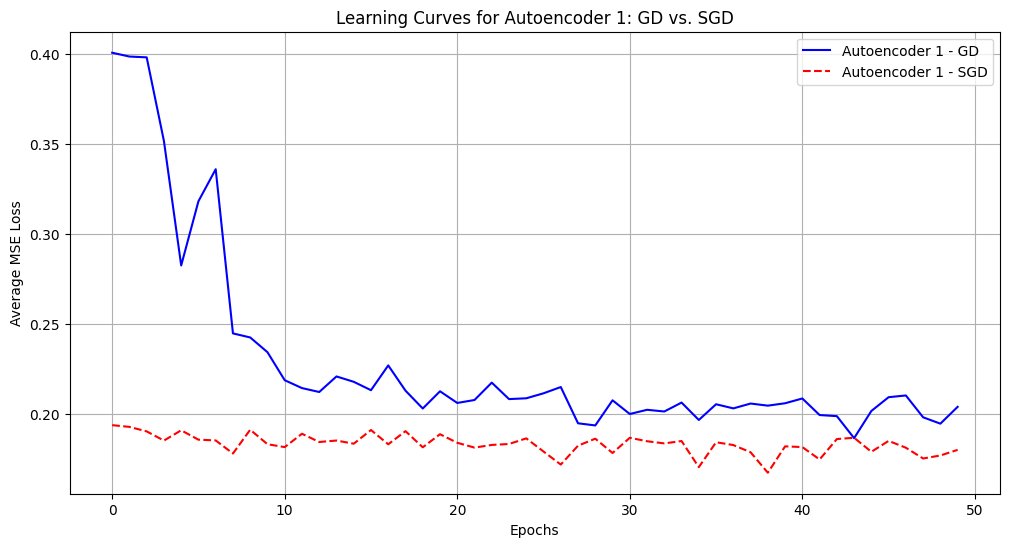

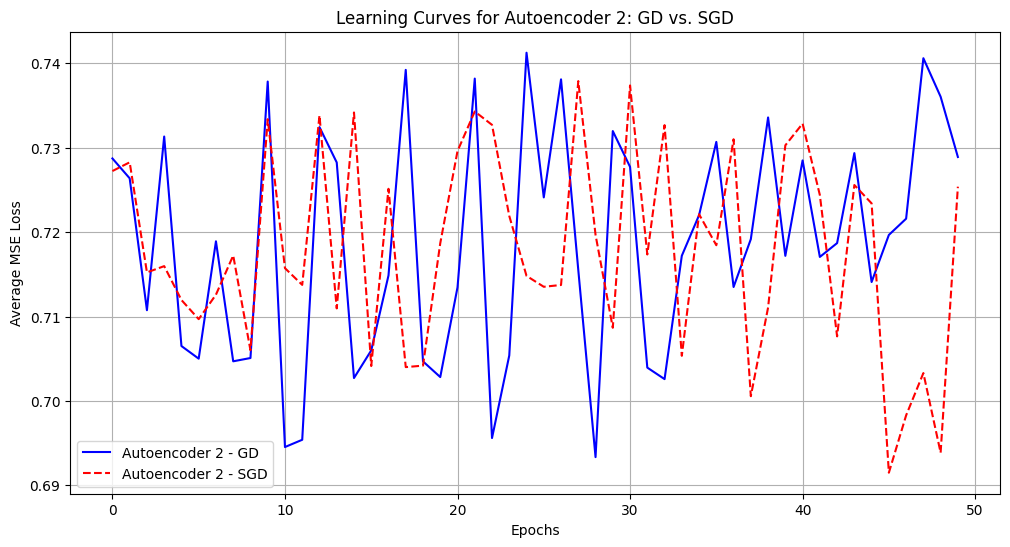

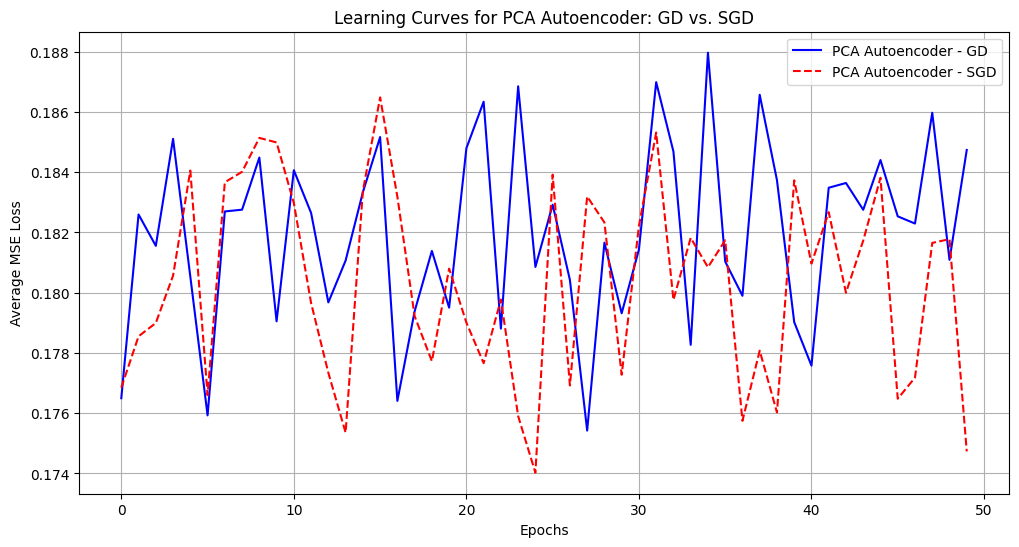

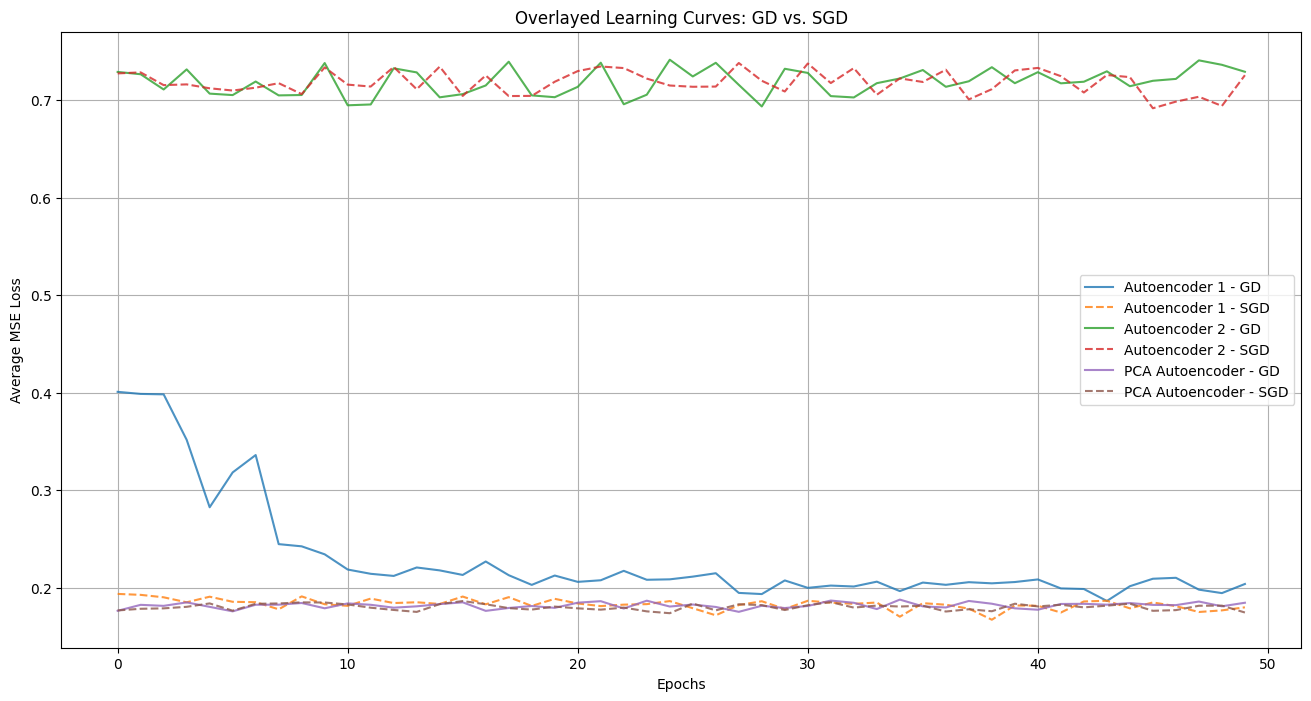

In [ ]:
# Function to train models with specified optimizers
def train_model_with_optimizer(model, data_loader, optimizer_type, epoch_count=50):
    """
    Train the model using the specified optimizer type and record the loss for each epoch.
    """
    # Select optimizer
    if optimizer_type == "gd":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # GD with momentum
    elif optimizer_type == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # Vanilla SGD
    else:
        raise ValueError(f"Unsupported optimizer type: {optimizer_type}")

    loss_fn = torch.nn.MSELoss()
    loss_curve = []

    for epoch in range(epoch_count):
        epoch_loss = 0
        for batch in data_loader:
            optimizer.zero_grad()
            x, _ = batch
            reconstructed = model(x)
            loss = loss_fn(reconstructed, x)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_curve.append(epoch_loss / len(data_loader))
    return loss_curve

# Function to train all models with both GD and SGD
def train_all_models_gd_sgd(models, data_loader, epoch_count=50):
    results = {}
    for name, model in models.items():
        print(f"Training {name} with Gradient Descent...")
        gd_loss_curve = train_model_with_optimizer(model, data_loader, optimizer_type="gd", epoch_count=epoch_count)

        print(f"Training {name} with Stochastic Gradient Descent...")
        sgd_loss_curve = train_model_with_optimizer(model, data_loader, optimizer_type="sgd", epoch_count=epoch_count)

        results[name] = {
            "GD": gd_loss_curve,
            "SGD": sgd_loss_curve
        }
    return results

# Train all models and collect results
training_results = train_all_models_gd_sgd(models, data_loader, epoch_count=50)

# Function to plot learning curves
def plot_learning_curves(training_results):
    for name, result in training_results.items():
        plt.figure(figsize=(12, 6))
        plt.plot(result["GD"], label=f"{name} - GD", color="blue")
        plt.plot(result["SGD"], label=f"{name} - SGD", color="red", linestyle="--")
        plt.title(f"Learning Curves for {name}: GD vs. SGD")
        plt.xlabel("Epochs")
        plt.ylabel("Average MSE Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

# Function to overlay learning curves for all models
def overlay_learning_curves(training_results):
    plt.figure(figsize=(16, 8))
    for name, result in training_results.items():
        plt.plot(result["GD"], label=f"{name} - GD", linestyle="-", alpha=0.8)
        plt.plot(result["SGD"], label=f"{name} - SGD", linestyle="--", alpha=0.8)
    plt.title("Overlayed Learning Curves: GD vs. SGD")
    plt.xlabel("Epochs")
    plt.ylabel("Average MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the learning curves
plot_learning_curves(training_results)
overlay_learning_curves(training_results)




#### **Part (h): Comparing Learning Curves**
1. **Autoencoder 1**:
   - **Learning Dynamics**: Both GD and SGD show noisy convergence due to the small model size. Loss plateaus at a relatively high value, reflecting the limited capacity of the model.
   - **Insights**: The learning process for a smaller autoencoder suffers from underfitting, which affects its ability to minimize the reconstruction error.

2. **Autoencoder 2**:
   - **Learning Dynamics**: Faster convergence and smoother loss curves, especially with GD. SGD shows initial rapid convergence but exhibits noise.
   - **Insights**: Larger architectures benefit from increased capacity, allowing for lower reconstruction errors and better generalization.

3. **PCA Autoencoder**:
   - **Learning Dynamics**: Convergence is fast and stable due to the simplicity of the architecture.
   - **Insights**: Linear reconstruction tasks are well-suited for PCA-based autoencoders, although they lack the flexibility of non-linear encoders.

4. **Visualization**:
   - Overlayed smoothed learning curves and variance plots illustrate the impact of optimizers and architectural complexity.






### Outcomes in the end:
- **Reconstruction Feasibility**: The Hilbert curve provides a benchmark for what perfect reconstruction looks like when mapping higher-dimensional data to 1D.
- **Model Comparisons**: Autoencoder 2 consistently outperforms the other autoencoders, showcasing the benefits of larger and more expressive architectures.
- **Learning Insights**: SGD is noisier but faster, while GD offers smoother convergence. Autoencoder size and complexity significantly affect learning dynamics and reconstruction quality.